<a href="https://colab.research.google.com/github/josueorellana/PrograIII-2024/blob/bloqueIII/IA_de_numeros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importar las librerias necesarias.
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import tensorflow_datasets as tfds

In [2]:
#cargamos el dataset
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)
datos_entrenamiento, datos_prueba = dataset['train'], dataset['test']
#print(datos_entrenamiento)

Dl Completed...:   0%|          | 0/5 [00:00<?, ? file/s]

Dataset mnist downloaded and prepared to /root/tensorflow_datasets/mnist/3.0.1. Subsequent calls will reuse this data.


In [3]:
#asignacion de etiquetas
numero_letras = ["Cero", "Uno", "Dos", "Tres", "Cuatro", "Cinco", "Seis", "Siete", "Ocho", "Nueve"]

In [4]:
#pasar los datos del dataset a variables
numeros_ejemplo_entrenamiento = metadata.splits['train'].num_examples
#print(numeros_ejemplo_entrenamiento)

numeros_ejemplo_prueba = metadata.splits['test'].num_examples
#print(numeros_ejemplo_prueba)

In [5]:
img = datos_prueba.take(1)
print(img)

<_TakeDataset element_spec=(TensorSpec(shape=(28, 28, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


In [6]:
#funcion normalizadora de los pixeles de 0 a 255 para que vaya de 0 a 1
def normalizacion(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes /= 255 # 138/255 = 0.541176
  return imagenes, etiquetas

In [7]:
#normalizamos los datos de entrenamiento y prueba
datos_entrenamiento = datos_entrenamiento.map(normalizacion)
datos_prueba = datos_prueba.map(normalizacion)

In [8]:
#creamos el modelo de nuestra red neuronal.
modelo = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
#compilamos el modelo de la red neuronal.
modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
#entrenamos la red neuronal por lotes.
tamano_lote = 32 #60,000/32 = 1875 imagenes.
datos_entrenamiento = datos_entrenamiento.repeat().shuffle(numeros_ejemplo_entrenamiento).batch(tamano_lote)
datos_prueba = datos_prueba.repeat().shuffle(numeros_ejemplo_prueba).batch(tamano_lote)


In [11]:
#entrenamos nuestro modelo de datos.
modelo.fit(datos_entrenamiento, epochs=5,
           steps_per_epoch=math.ceil(numeros_ejemplo_entrenamiento/tamano_lote))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.8584 - loss: 0.4866
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9602 - loss: 0.1325
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9712 - loss: 0.0938
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9778 - loss: 0.0711
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9804 - loss: 0.0594


In [12]:
#evaluamos el modelo.
test_loss, test_accuracy = modelo.evaluate(datos_prueba, steps=math.ceil(numeros_ejemplo_prueba/tamano_lote))
print('Resultado de las pruebas: ', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9788 - loss: 0.0759
Resultado de las pruebas:  0.9763378500938416


In [13]:
#convertir en mtrices las imganes usando numpy
for imagenes_prueba, etiquetas_prueba in datos_prueba.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)
  print(predicciones)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
[[8.22996324e-11 6.94793471e-07 9.99998987e-01 1.72952880e-07
  9.91758853e-09 6.26023189e-09 3.17028857e-08 7.78968072e-08
  1.16108358e-08 3.50237395e-09]
 [8.19563510e-08 3.99170858e-06 9.99935567e-01 2.09878108e-05
  8.81491688e-15 5.48976153e-08 2.80137282e-08 1.40482834e-05
  2.51334004e-05 5.87646944e-08]
 [9.99991238e-01 1.00959063e-08 2.68498411e-07 6.30113392e-11
  3.15606720e-12 1.11507488e-08 2.46499758e-06 2.94188271e-06
  1.32808570e-10 2.99542353e-06]
 [9.99993503e-01 1.27776123e-10 5.16502041e-09 9.77146857e-13
  5.00959777e-12 1.12710747e-08 1.33765286e-06 1.41886574e-07
  4.19372453e-11 5.06313791e-06]
 [1.64584821e-11 8.54952442e-10 2.46542697e-09 2.49951698e-10
  9.99995291e-01 1.20453734e-07 1.03708798e-10 1.51437052e-06
  5.70475978e-09 2.91596803e-06]
 [1.03521441e-10 1.59225777e-09 2.45138949e-06 1.82009330e-07
  3.74068554e-10 1.17165975e-08 2.78327274e-11 1.49187649e-08
  9.99997199e-01 6.21015630e-08]
 [1.66511889e-12 6.8

In [14]:
def graficar_imagen(i, predicciones_array, etiquetas_reales, imagenes):
  predicciones_array, etiqueta_real, img = predicciones_array[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(predicciones_array)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'
  plt.xlabel("Prediccion: {}".format(numero_letras[etiqueta_prediccion]), color=color)

In [15]:
#graficamos los valores de las matrices.
def graficar_valores_predicciones(i, predicciones_array, etiquetas_reales):
  predicciones_array, etiqueta_real = predicciones_array[i], etiquetas_reales[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predicciones_array, color="#888888")
  plt.ylim([0, 1])
  etiqueta_prediccion = np.argmax(predicciones_array)

  thisplot[etiqueta_prediccion].set_color('red')
  thisplot[etiqueta_real].set_color('blue')

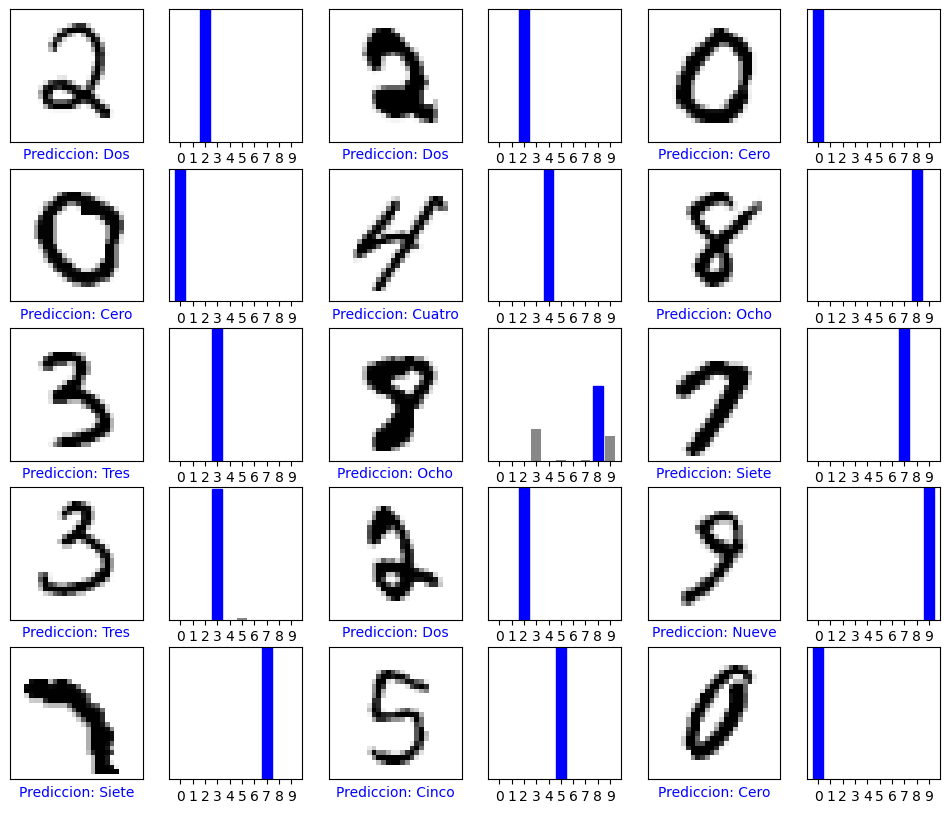

In [16]:
#Realizamos la grafica por cada imagen.
num_filas = 5
num_columnas = 3
num_imagenes = num_filas*num_columnas
plt.figure(figsize=(2*2*num_columnas, 2*num_filas))
for i in range(num_imagenes):
  plt.subplot(num_filas, 2*num_columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(num_filas, 2*num_columnas, 2*i+2)
  graficar_valores_predicciones(i, predicciones, etiquetas_prueba)
plt.show()